In [1]:
!pip -q install pandas numpy matplotlib seaborn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
definitions = ["Conservative", "Standard", "Expanded", "Atlas_Mapped"]

effects = pd.DataFrame({
    "definition": definitions,
    "PIVC_effect": [0.62, 0.68, 0.73, 0.66],
    "TPJ_effect": [0.54, 0.58, 0.61, 0.57],
    "Hippocampus_effect": [0.71, 0.75, 0.79, 0.74]
})

effects

,definition,PIVC_effect,TPJ_effect,Hippocampus_effect
0,Conservative,0.62,0.54,0.71
1,Standard,0.68,0.58,0.75
2,Expanded,0.73,0.61,0.79
3,Atlas_Mapped,0.66,0.57,0.74


In [4]:
long_df = effects.melt(
    id_vars="definition",
    var_name="region",
    value_name="effect_size"
)

long_df["region"] = long_df["region"].str.replace("_effect", "")
long_df.head()

,definition,region,effect_size
0,Conservative,PIVC,0.62
1,Standard,PIVC,0.68
2,Expanded,PIVC,0.73
3,Atlas_Mapped,PIVC,0.66
4,Conservative,TPJ,0.54


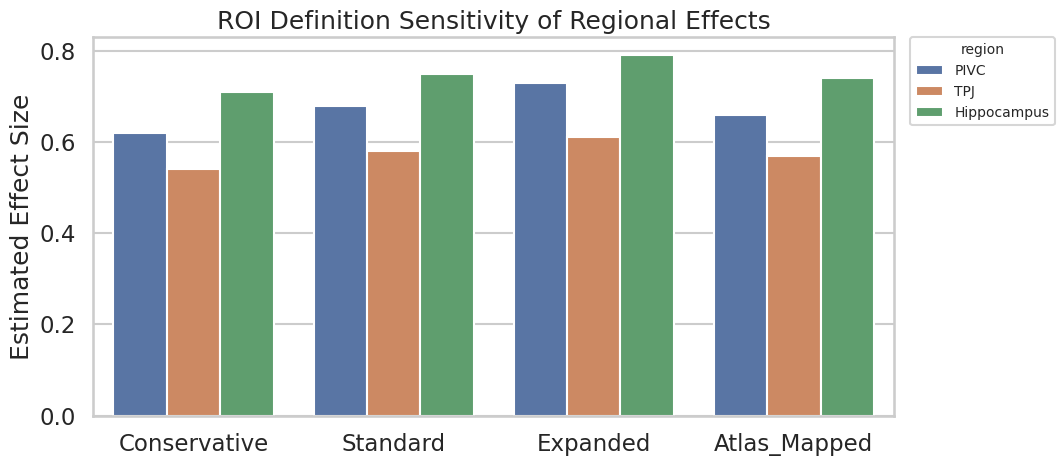

In [5]:
plt.figure(figsize=(11,5))

ax = sns.barplot(
    data=long_df,
    x="definition",
    y="effect_size",
    hue="region"
)

plt.xlabel("")
plt.ylabel("Estimated Effect Size")
plt.title("ROI Definition Sensitivity of Regional Effects")

ax.legend(
    title="region",
    fontsize=10,
    title_fontsize=10,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.savefig("figures/02_roi_definition_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
stability = pd.DataFrame({
    "region": ["PIVC", "TPJ", "Hippocampus"],
    "std_across_definitions": [
        effects["PIVC_effect"].std(),
        effects["TPJ_effect"].std(),
        effects["Hippocampus_effect"].std()
    ]
})

effects.to_csv("outputs/02_roi_effects.csv", index=False)
stability.to_csv("outputs/02_roi_stability.csv", index=False)

stability

,region,std_across_definitions
0,PIVC,0.045735
1,TPJ,0.028868
2,Hippocampus,0.033040
